# 🤖 Machine Learning Wrapup - Part I

* Le Wagon Online - Batch 2007 - Data Science (taught in French)
* Q2 2025
* Davy WAI


⚠️ This notebook sums up what students from Batch 2007 - Online learned in Machine Learning from Wed 7 to Tue 13 May 2025. It can NEITHER be reproduced by Le Wagon, NOR RE-USED by another TA or teacher NOR uploaded to Kitt without my permission.

## (0) Libraries 📚

In [1]:
# Data Manipulation
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
### PREPROCESSING
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
### MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
### METRICS
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import classification_report
### FINE TUNING
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


##  (1) Dataset 💾

In [2]:
airline_satisfaction = "https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/Reboot-2/Invistico_Airline.csv"

In [3]:
data = pd.read_csv(airline_satisfaction)

In [4]:
data.head()

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,2,4,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,0,2,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,2,0,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,3,4,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,4,3,4,2,2,0,2,4,2,5,0,0.0


###  (1.1) Basic Info ℹ️

In [5]:
data.shape

(129880, 23)

In [6]:
y = data["satisfaction"]=="satisfied"
y.value_counts()

True     71087
False    58793
Name: satisfaction, dtype: int64

In [7]:
round(y.value_counts(normalize=True),2)

True     0.55
False    0.45
Name: satisfaction, dtype: float64

In [8]:
data.dtypes

satisfaction                          object
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Seat comfort                           int64
Departure/Arrival time convenient      int64
Food and drink                         int64
Gate location                          int64
Inflight wifi service                  int64
Inflight entertainment                 int64
Online support                         int64
Ease of Online booking                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Online boarding                        int64
Departure Delay in Minutes             int64
Arrival De

<Axes: ylabel='None'>

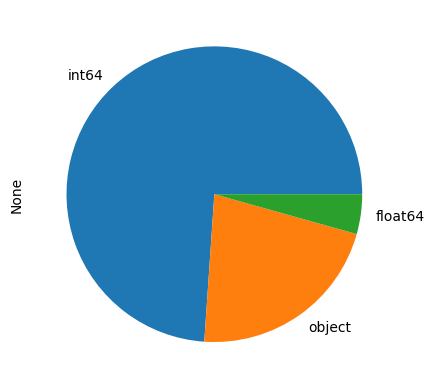

In [9]:
data.dtypes.value_counts().plot(kind="pie")

###  (1.2) Pre-cleaning 🕵🏻‍♂️

* 👥 Remove duplicates
* ❓ Have a first glimpse at the missing values
* 😏 Detect the weird columns
* ⚖️ Detect class imbalances for classification tasks and outliers for regression tasks

***Duplicates***

In [10]:
nb_of_duplicated_rows = data.duplicated().sum()
nb_of_duplicated_rows

0

In [11]:
data = data.drop_duplicates()

***Missing values???***

In [12]:
data.isna().sum().sort_values(ascending=False)

Arrival Delay in Minutes             393
Inflight entertainment                 0
Departure Delay in Minutes             0
Online boarding                        0
Cleanliness                            0
Checkin service                        0
Baggage handling                       0
Leg room service                       0
On-board service                       0
Ease of Online booking                 0
Online support                         0
satisfaction                           0
Gender                                 0
Gate location                          0
Food and drink                         0
Departure/Arrival time convenient      0
Seat comfort                           0
Flight Distance                        0
Class                                  0
Type of Travel                         0
Age                                    0
Customer Type                          0
Inflight wifi service                  0
dtype: int64

In [13]:
data.isna().mean().sort_values(ascending=False)

Arrival Delay in Minutes             0.003026
Inflight entertainment               0.000000
Departure Delay in Minutes           0.000000
Online boarding                      0.000000
Cleanliness                          0.000000
Checkin service                      0.000000
Baggage handling                     0.000000
Leg room service                     0.000000
On-board service                     0.000000
Ease of Online booking               0.000000
Online support                       0.000000
satisfaction                         0.000000
Gender                               0.000000
Gate location                        0.000000
Food and drink                       0.000000
Departure/Arrival time convenient    0.000000
Seat comfort                         0.000000
Flight Distance                      0.000000
Class                                0.000000
Type of Travel                       0.000000
Age                                  0.000000
Customer Type                     

## (2)💈Preprocessing

In [14]:
X = data.drop(columns=["satisfaction"])
X.shape

(129880, 22)

### (2.0) ✂️ Train-test-split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y)

### (2.1) 🔢 Numerical values: Scaling

In [16]:
# X_num = X.select_dtypes(include=["int64", "float64"])
X_num = X.select_dtypes(include=np.number)
X_num.head()

,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,65,265,0,0,0,2,2,4,2,3,3,0,3,5,3,2,0,0.0
1,47,2464,0,0,0,3,0,2,2,3,4,4,4,2,3,2,310,305.0
2,15,2138,0,0,0,3,2,0,2,2,3,3,4,4,4,2,0,0.0
3,60,623,0,0,0,3,3,4,3,1,1,0,1,4,1,3,0,0.0
4,70,354,0,0,0,3,4,3,4,2,2,0,2,4,2,5,0,0.0


In [17]:
X_num.columns

Index(['Age', 'Flight Distance', 'Seat comfort',
       'Departure/Arrival time convenient', 'Food and drink', 'Gate location',
       'Inflight wifi service', 'Inflight entertainment', 'Online support',
       'Ease of Online booking', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes'],
      dtype='object')

In [18]:
len(X_num.columns)

18

--------------------------------------------------


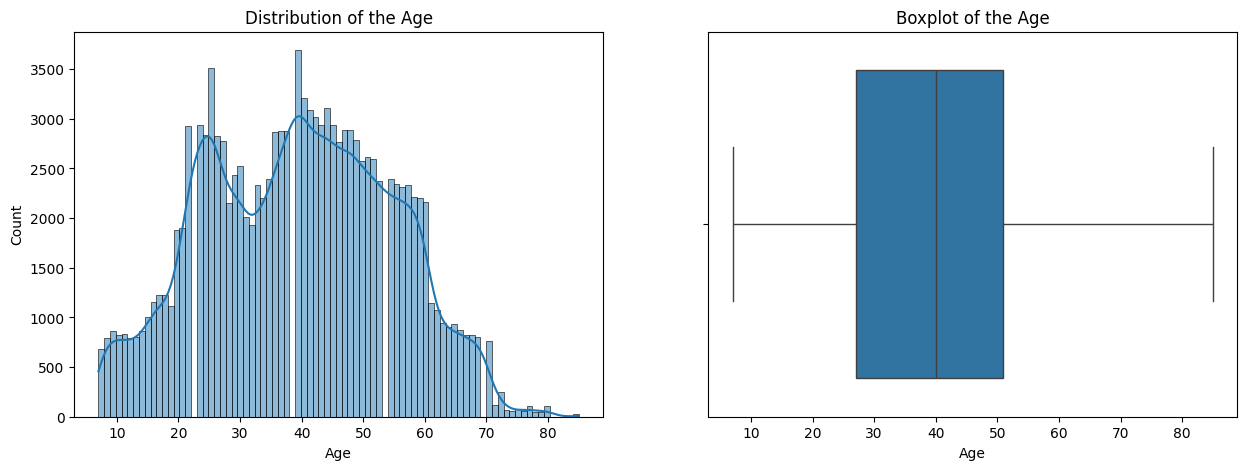

--------------------------------------------------


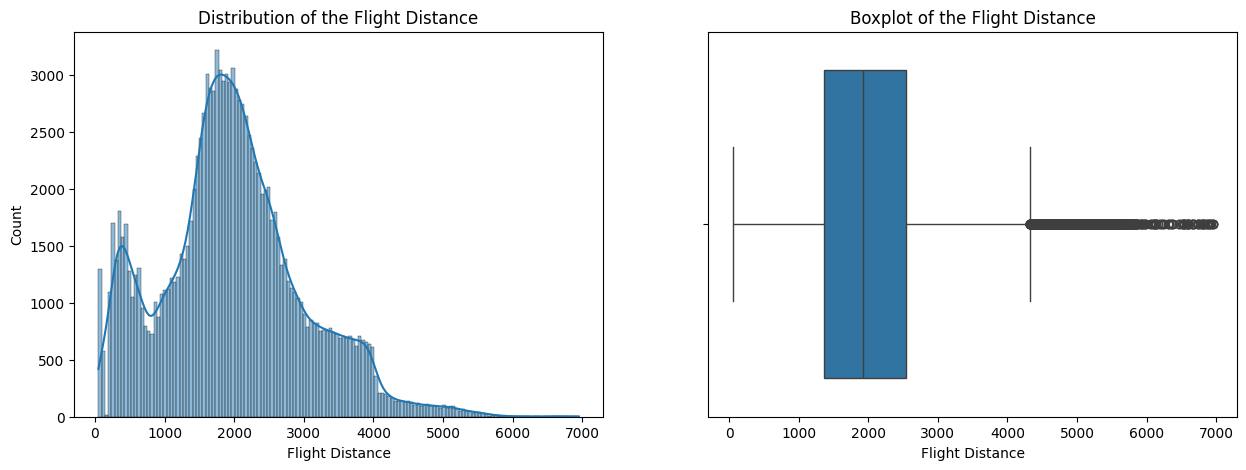

--------------------------------------------------


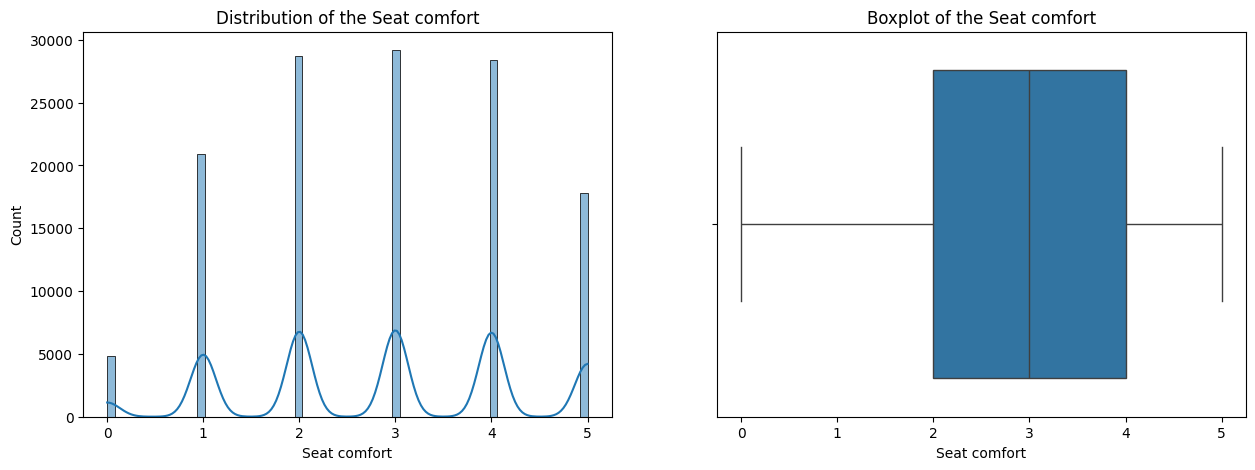

--------------------------------------------------


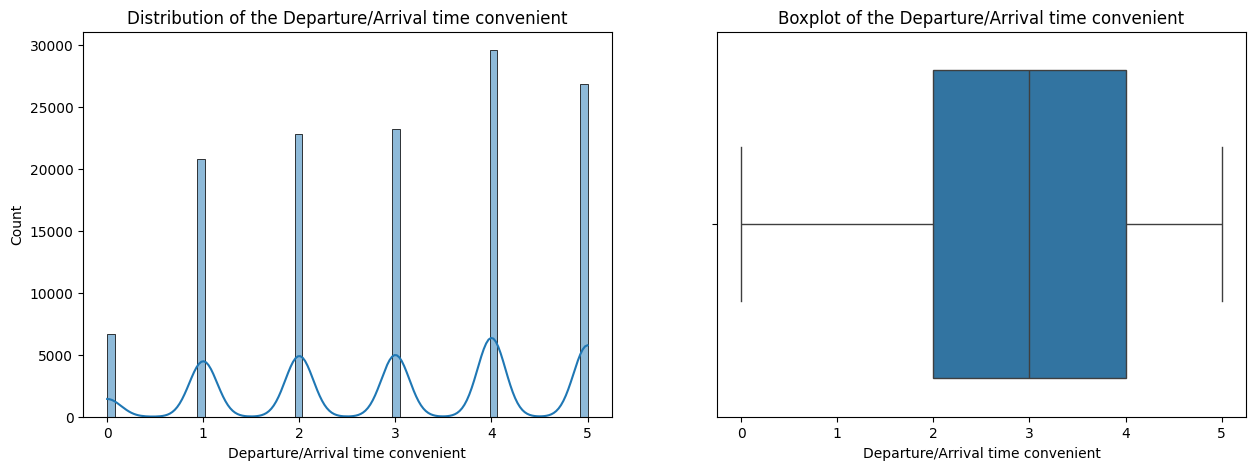

--------------------------------------------------


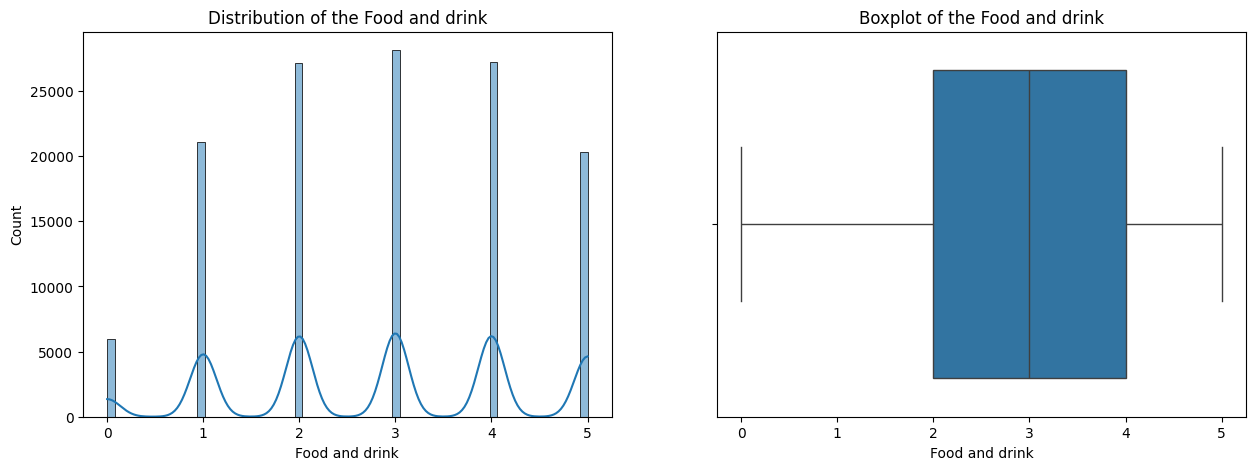

--------------------------------------------------


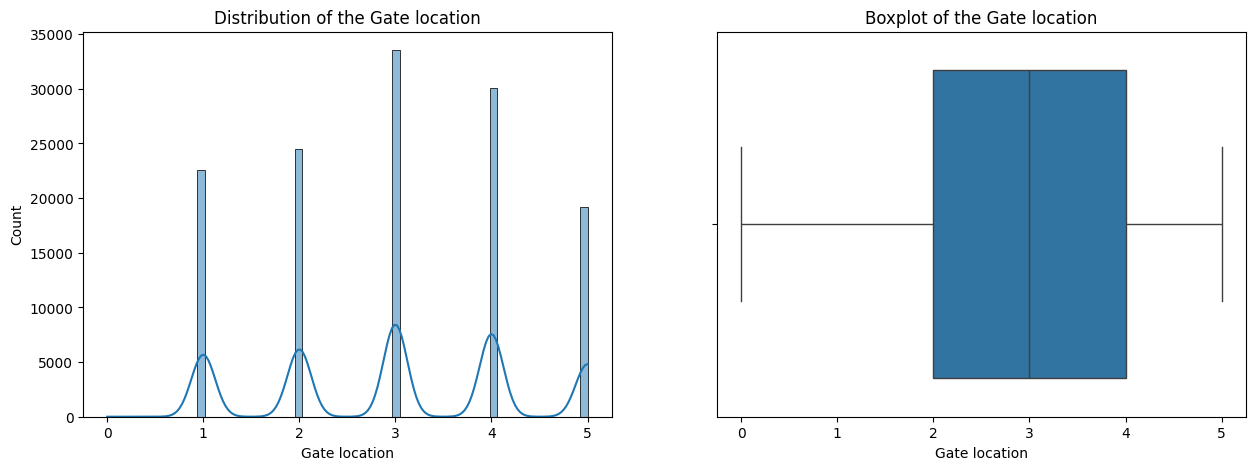

--------------------------------------------------


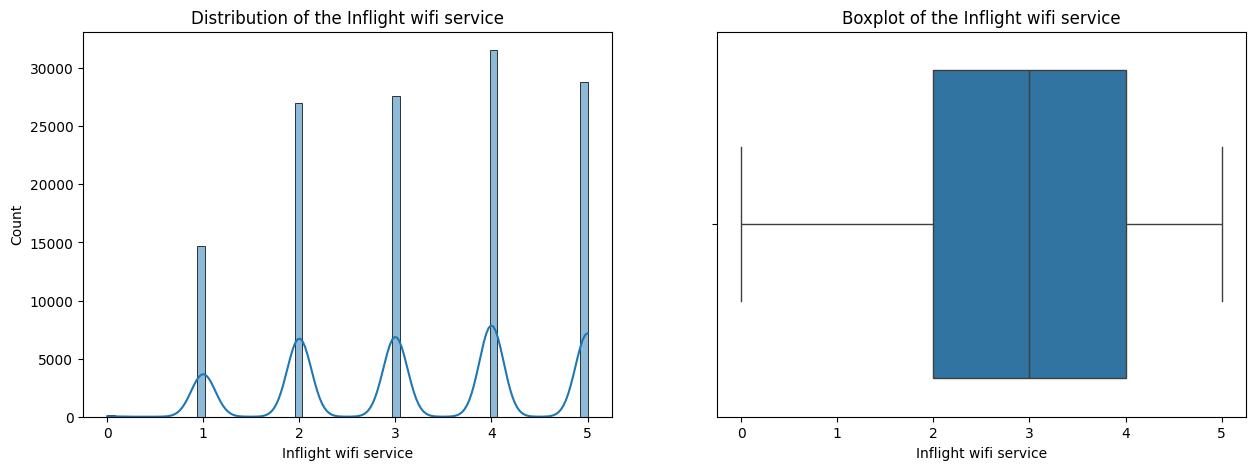

--------------------------------------------------


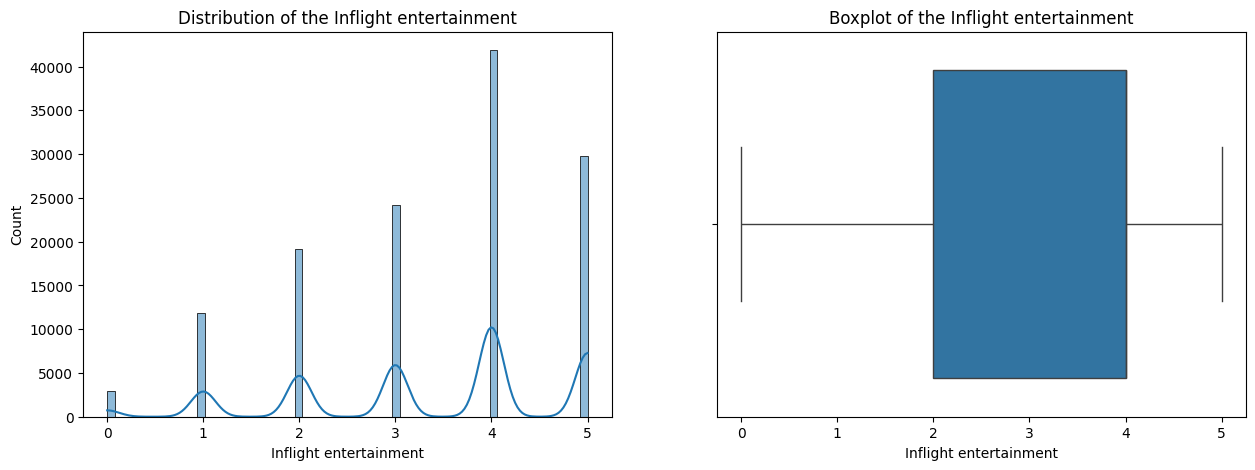

--------------------------------------------------


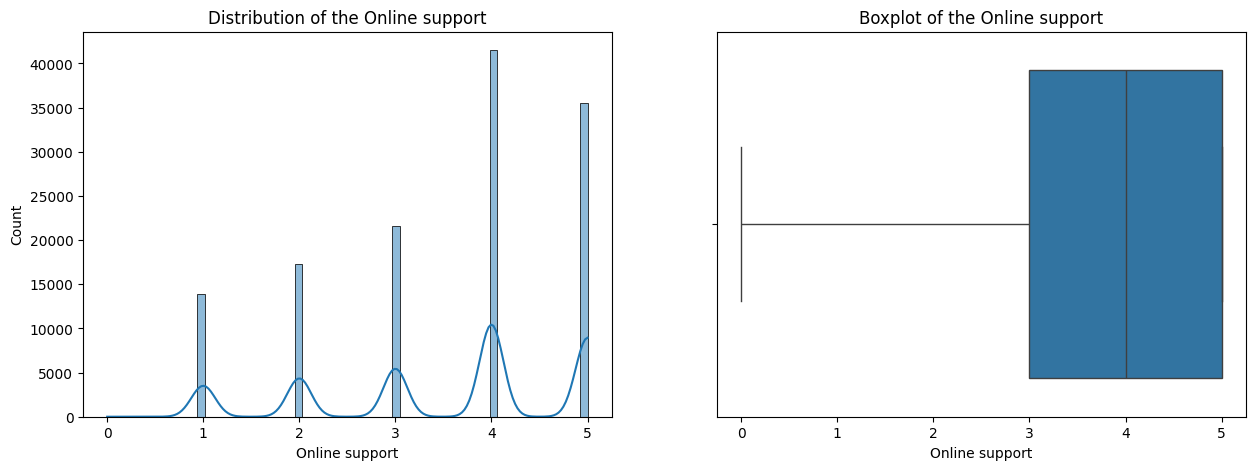

--------------------------------------------------


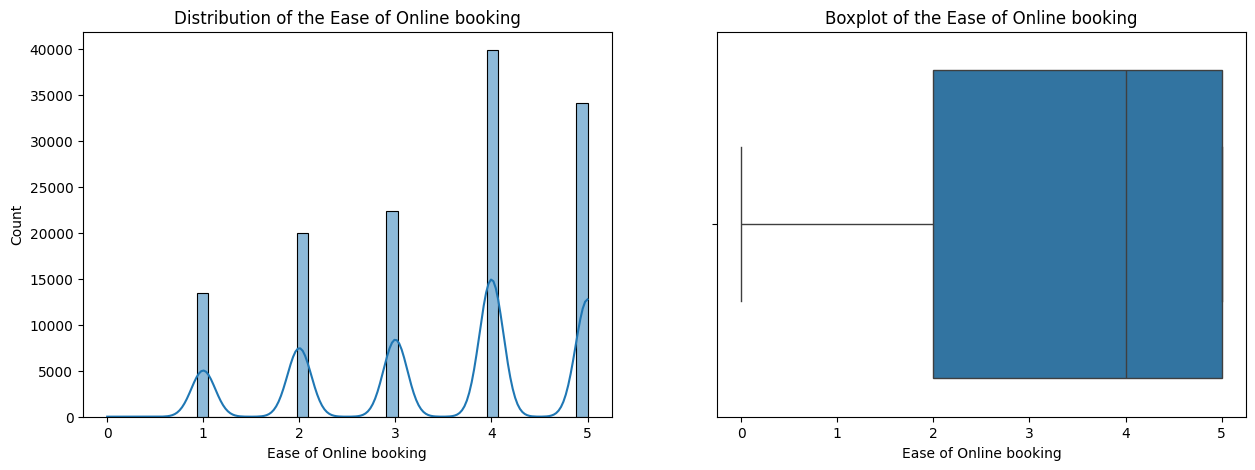

--------------------------------------------------


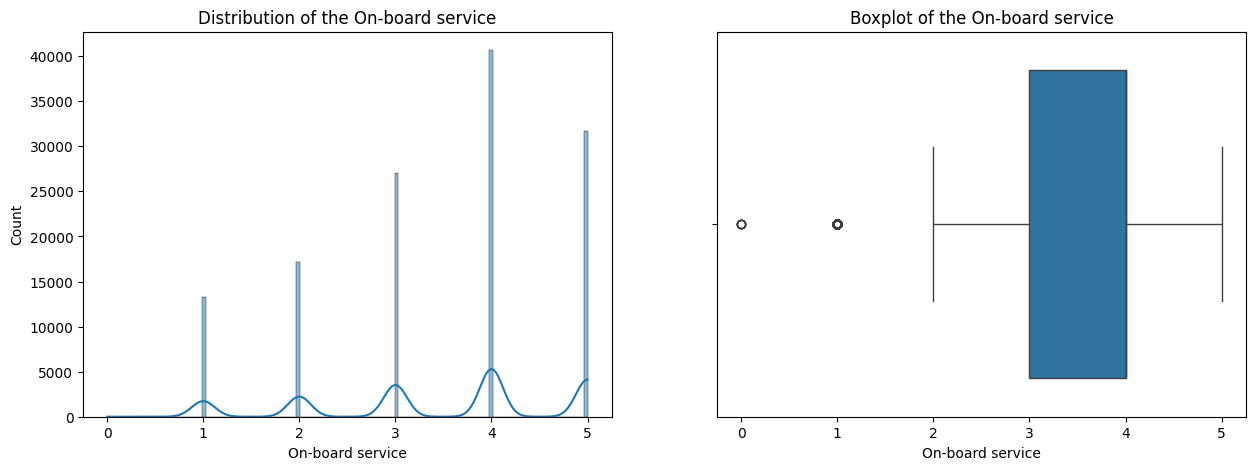

--------------------------------------------------


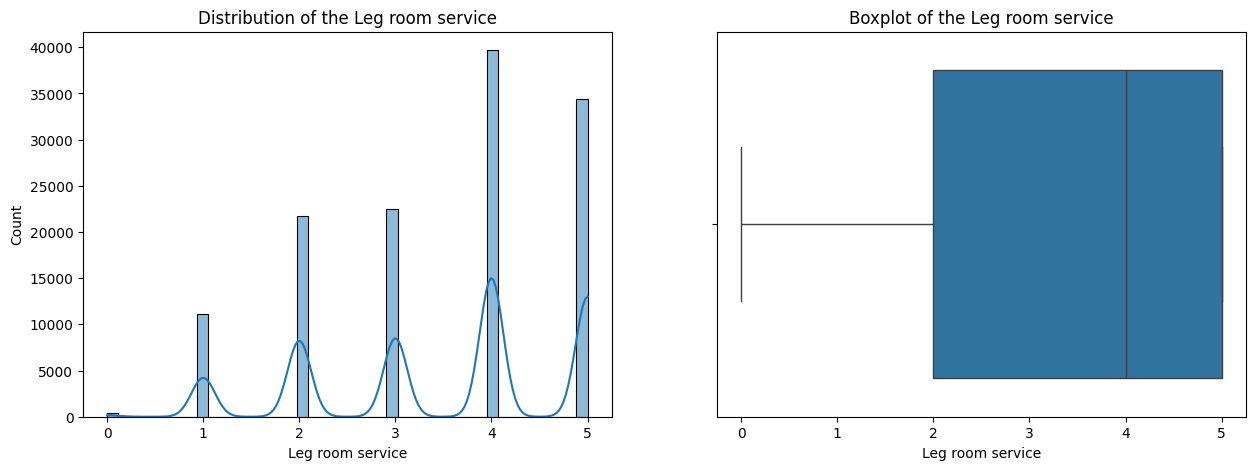

--------------------------------------------------


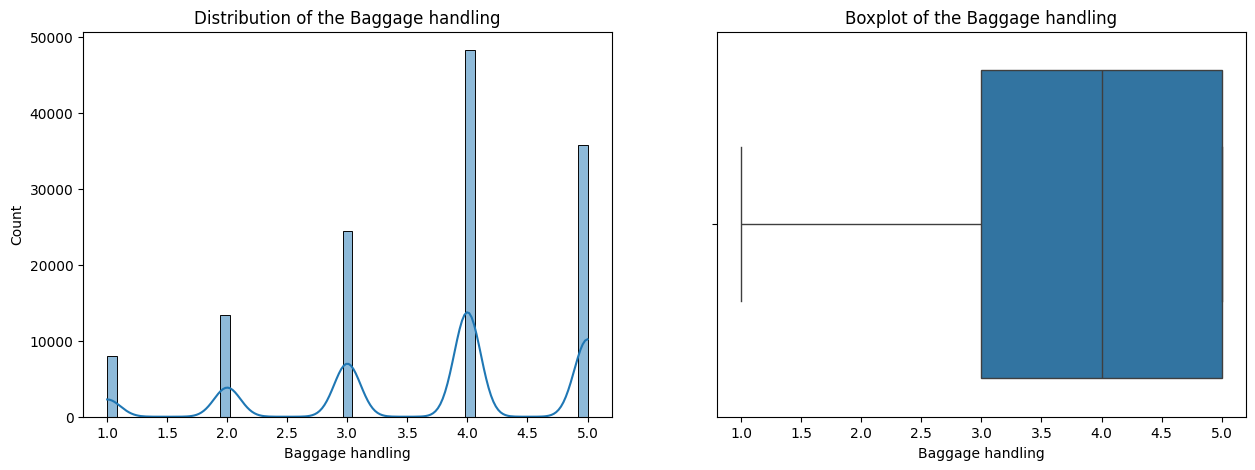

--------------------------------------------------


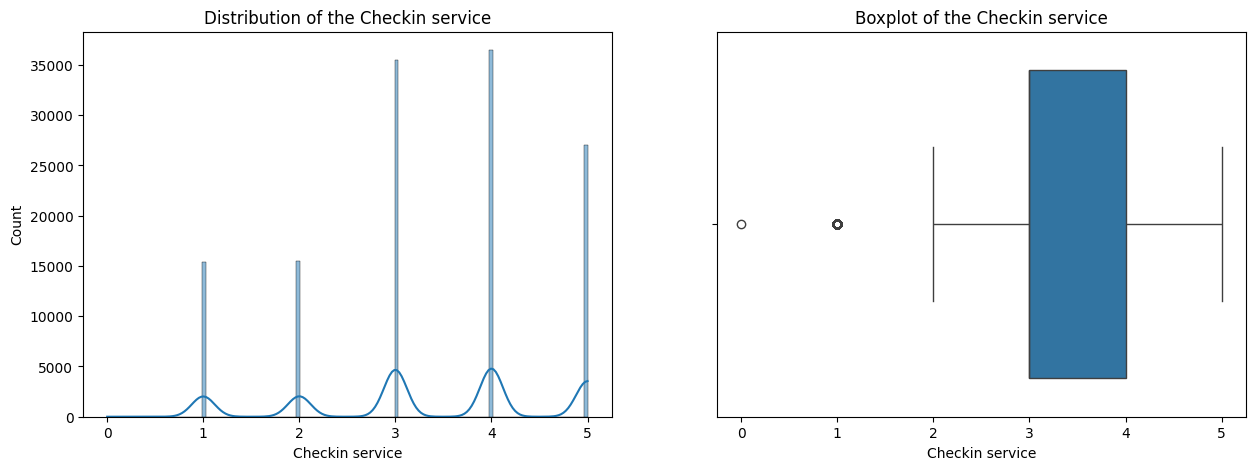

--------------------------------------------------


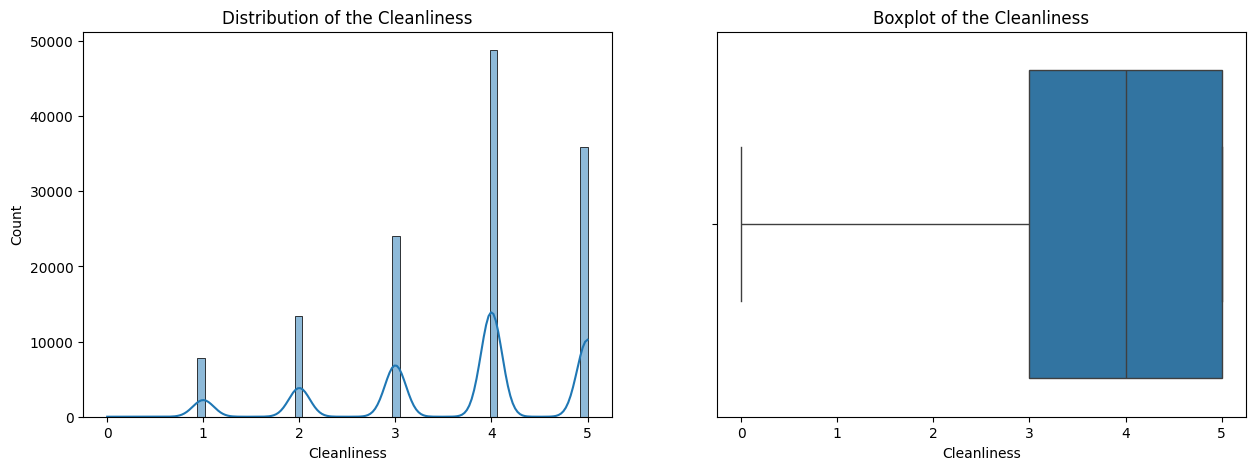

--------------------------------------------------


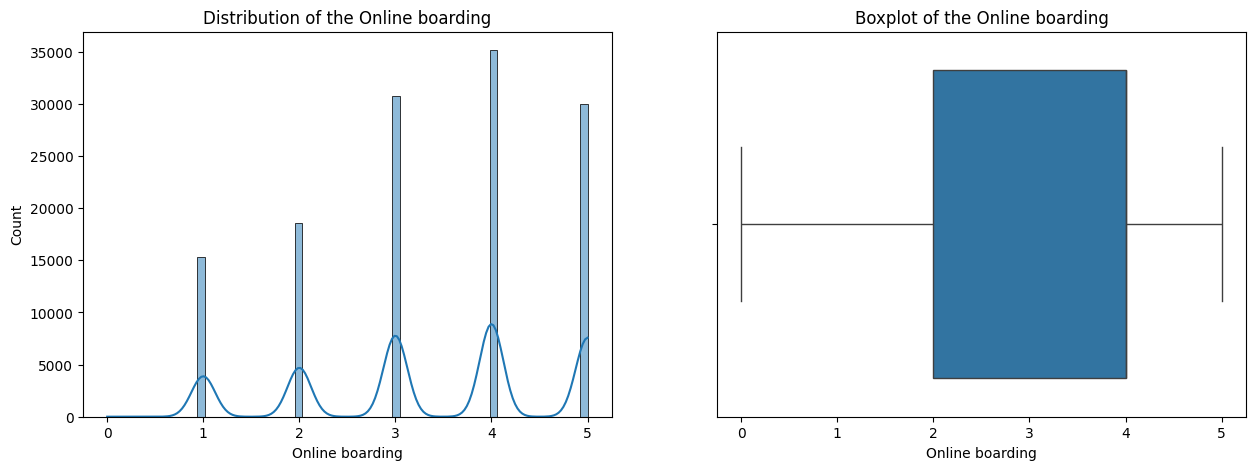

--------------------------------------------------


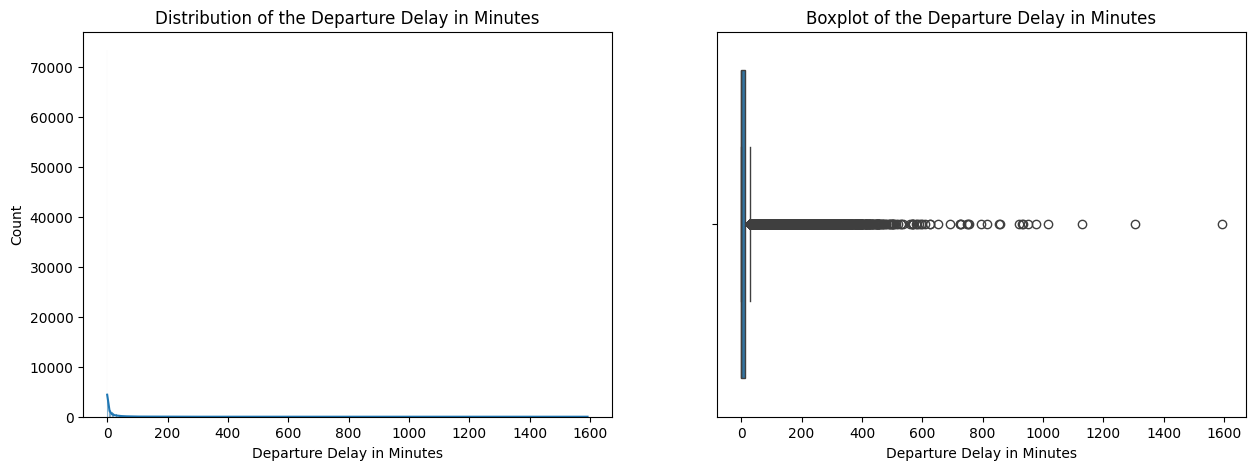

--------------------------------------------------


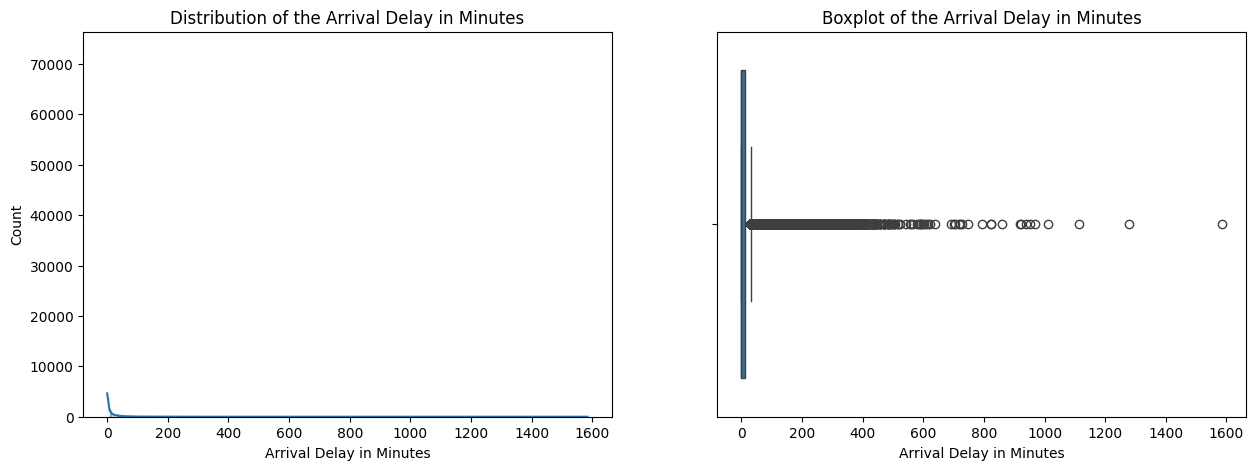

In [19]:
for variable in list(X_num.columns):
    print("-"*50)

    fig, ax = plt.subplots(1,2,figsize=(15,5))

    ax[0].set_title(f"Distribution of the {variable}")
    sns.histplot(data = X_num, x = f"{variable}", kde=True, ax = ax[0])

    ax[1].set_title(f"Boxplot of the {variable}")
    sns.boxplot(data = X_num, x = f"{variable}", ax=ax[1])

    plt.show();

In [20]:
robust_features = ["Flight Distance"]
standard_features = ["Age", ]
minmax_features = ["Seat comfort", "Departure/Arrival time convenient", "Food and drink",
                   "Gate location", "Inflight wifi service", "Inflight entertainment",
                   "Online support", "Ease of Online booking", "On-board service",
                   "Leg room service", "Baggage handling", "Checkin service",
                   "Cleanliness", "Online boarding", "Departure Delay in Minutes",
                   "Arrival Delay in Minutes"]

In [21]:
scalers = ColumnTransformer([
    ("rob", RobustScaler(), robust_features), # Robust
    ("std", StandardScaler(), standard_features), # Std
    ("mm", MinMaxScaler(), minmax_features), # MinMax
])

scalers

ColumnTransformer(transformers=[('rob', RobustScaler(), ['Flight Distance']),
                                ('std', StandardScaler(), ['Age']),
                                ('mm', MinMaxScaler(),
                                 ['Seat comfort',
                                  'Departure/Arrival time convenient',
                                  'Food and drink', 'Gate location',
                                  'Inflight wifi service',
                                  'Inflight entertainment', 'Online support',
                                  'Ease of Online booking', 'On-board service',
                                  'Leg room service', 'Baggage handling',
                                  'Checkin service', 'Cleanliness',
                                  'Online boarding',
                                  'Departure Delay in Minutes',
                                  'Arrival Delay in Minutes'])])

In [22]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scalers", scalers)
]).set_output(transform="pandas")

numerical_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scalers',
                 ColumnTransformer(transformers=[('rob', RobustScaler(),
                                                  ['Flight Distance']),
                                                 ('std', StandardScaler(),
                                                  ['Age']),
                                                 ('mm', MinMaxScaler(),
                                                  ['Seat comfort',
                                                   'Departure/Arrival time '
                                                   'convenient',
                                                   'Food and drink',
                                                   'Gate location',
                                                   'Inflight wifi service',
                                                   'Inflight entertainment',
                                                   'Online support',
                                                   'Ease of Online booking',
                                                   'On-board service',
                                                   'Leg room service',
                                                   'Baggage handling',
                                                   'Checkin service',
                                                   'Cleanliness',
                                                   'Online boarding',
                                                   'Departure Delay in Minutes',
                                                   'Arrival Delay in '
                                                   'Minutes'])]))])

In [23]:
numerical_pipeline.fit_transform(X_num)

,rob__Flight Distance,std__Age,mm__Seat comfort,mm__Departure/Arrival time convenient,mm__Food and drink,mm__Gate location,mm__Inflight wifi service,mm__Inflight entertainment,mm__Online support,mm__Ease of Online booking,mm__On-board service,mm__Leg room service,mm__Baggage handling,mm__Checkin service,mm__Cleanliness,mm__Online boarding,mm__Departure Delay in Minutes,mm__Arrival Delay in Minutes
0,-1.400844,1.691351,0.0,0.0,0.0,0.4,0.4,0.8,0.4,0.6,0.6,0.0,0.50,1.0,0.6,0.4,0.000000,0.000000
1,0.454852,0.500820,0.0,0.0,0.0,0.6,0.0,0.4,0.4,0.6,0.8,0.8,0.75,0.4,0.6,0.4,0.194724,0.192551
2,0.179747,-1.615680,0.0,0.0,0.0,0.6,0.4,0.0,0.4,0.4,0.6,0.6,0.75,0.8,0.8,0.4,0.000000,0.000000
3,-1.098734,1.360648,0.0,0.0,0.0,0.6,0.6,0.8,0.6,0.2,0.2,0.0,0.00,0.8,0.2,0.6,0.000000,0.000000
4,-1.325738,2.022054,0.0,0.0,0.0,0.6,0.8,0.6,0.8,0.4,0.4,0.0,0.25,0.8,0.4,1.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,-0.163713,-0.689712,1.0,1.0,1.0,0.6,0.4,1.0,0.4,0.4,0.6,0.6,0.75,0.8,0.8,0.4,0.000000,0.000000
129876,0.136709,1.559070,0.4,0.6,0.4,0.8,0.4,0.2,0.2,0.6,0.4,0.6,0.50,0.2,0.4,0.2,0.109296,0.108586
129877,0.333333,1.955913,0.6,0.0,0.6,0.6,0.6,0.4,0.4,0.8,0.8,0.6,0.75,0.4,0.6,0.4,0.097362,0.102904
129878,0.443038,1.757491,0.6,0.4,0.6,0.4,0.6,0.4,0.4,0.6,0.6,0.4,0.50,0.4,0.2,0.4,0.121231,0.129419


### (2.2) 🔡 Categorical values: Encoding

In [24]:
# X_num = X.select_dtypes(include=["int64", "float64"])
X_cat = X.select_dtypes(exclude=np.number)
X_cat.head()

,Gender,Customer Type,Type of Travel,Class
0,Female,Loyal Customer,Personal Travel,Eco
1,Male,Loyal Customer,Personal Travel,Business
2,Female,Loyal Customer,Personal Travel,Eco
3,Female,Loyal Customer,Personal Travel,Eco
4,Female,Loyal Customer,Personal Travel,Eco


In [25]:
for feature in list(X_cat.columns):
    print("-"*50)
    print(f"The different values for {feature} are:")
    display(X_cat[feature].value_counts(dropna=False))

--------------------------------------------------
The different values for Gender are:


Female    65899
Male      63981
Name: Gender, dtype: int64

--------------------------------------------------
The different values for Customer Type are:


Loyal Customer       106100
disloyal Customer     23780
Name: Customer Type, dtype: int64

--------------------------------------------------
The different values for Type of Travel are:


Business travel    89693
Personal Travel    40187
Name: Type of Travel, dtype: int64

--------------------------------------------------
The different values for Class are:


Business    62160
Eco         58309
Eco Plus     9411
Name: Class, dtype: int64

In [26]:
ordinal_features = ["Customer Type", "Class"]
onehot_features = ["Gender", "Type of Travel"]

#### (2.2.1) 🥇🥈🥉 Ordinal Encoding

In [27]:
ordinal_features_dict = {
    "Customer Type":["disloyal Customer", "Loyal Customer"],
    "Class":["Eco", "Eco Plus", "Business"]
}

In [28]:
ordinal_values =  list(ordinal_features_dict.values())
ordinal_values

[['disloyal Customer', 'Loyal Customer'], ['Eco', 'Eco Plus', 'Business']]

In [29]:
# ordinal_values = [ordinal_features_dict[key] for key in ordinal_features_dict.keys()]
# ordinal_values

In [30]:
ordinal_encoder = OrdinalEncoder(
    categories = ordinal_values,
    dtype = np.int64,
    handle_unknown = "use_encoded_value",
    unknown_value = -1).set_output(transform="pandas")

In [31]:
ordinal_encoder.fit_transform(X_cat[ordinal_features])

,Customer Type,Class
0,1,0
1,1,2
2,1,0
3,1,0
4,1,0
...,...,...
129875,0,0
129876,0,2
129877,0,0
129878,0,0


#### (2.2.2) 🐱🐶🦊 OneHot Encoding

In [32]:
onehot = OneHotEncoder(
    sparse_output=False,
    drop="if_binary",
    handle_unknown="ignore"
).set_output(transform="pandas")

In [33]:
onehot.fit_transform(X_cat[onehot_features])

,Gender_Male,Type of Travel_Personal Travel
0,0.0,1.0
1,1.0,1.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0
...,...,...
129875,0.0,1.0
129876,1.0,1.0
129877,1.0,1.0
129878,1.0,1.0


In [34]:
encoders = ColumnTransformer([
    ("ord", ordinal_encoder,ordinal_features), # Ordinal
    ("one_hot", onehot, onehot_features) # OHE
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoders", encoders)
]).set_output(transform="pandas")

categorical_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoders',
                 ColumnTransformer(transformers=[('ord',
                                                  OrdinalEncoder(categories=[['disloyal '
                                                                              'Customer',
                                                                              'Loyal '
                                                                              'Customer'],
                                                                             ['Eco',
                                                                              'Eco '
                                                                              'Plus',
                                                                              'Business']],
                                                                 dtype=<class 'numpy.int64'>,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['Customer Type', 'Class']),
                                                 ('one_hot',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Gender',
                                                   'Type of Travel'])]))])

In [35]:
categorical_pipeline.fit_transform(X_cat)

,ord__Customer Type,ord__Class,one_hot__Gender_Male,one_hot__Type of Travel_Personal Travel
0,1,0,0.0,1.0
1,1,2,1.0,1.0
2,1,0,0.0,1.0
3,1,0,0.0,1.0
4,1,0,0.0,1.0
...,...,...,...,...
129875,0,0,0.0,1.0
129876,0,2,1.0,1.0
129877,0,0,1.0,1.0
129878,0,0,1.0,1.0


## (2.3) 🦾 Final Preprocessor

In [36]:
data.dtypes

satisfaction                          object
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Seat comfort                           int64
Departure/Arrival time convenient      int64
Food and drink                         int64
Gate location                          int64
Inflight wifi service                  int64
Inflight entertainment                 int64
Online support                         int64
Ease of Online booking                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Online boarding                        int64
Departure Delay in Minutes             int64
Arrival De

In [37]:
preprocessor = ColumnTransformer([
    ("num_pipeline", numerical_pipeline, make_column_selector(dtype_include = np.number)), # num_features
    ("cat_pipeline", categorical_pipeline,make_column_selector(dtype_exclude = np.number)) # cat_features
]).set_output(transform="pandas")

preprocessor

ColumnTransformer(transformers=[('num_pipeline',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scalers',
                                                  ColumnTransformer(transformers=[('rob',
                                                                                   RobustScaler(),
                                                                                   ['Flight '
                                                                                    'Distance']),
                                                                                  ('std',
                                                                                   StandardScaler(),
                                                                                   ['Age']),
                                                                                  ('mm',
                                                                                   MinMaxScaler(),
                                                                                   ['Seat '
                                                                                    'comfort',
                                                                                    'Departure/Arrival '
                                                                                    'time '
                                                                                    'convenient',
                                                                                    'Food '
                                                                                    'and '
                                                                                    'drink',
                                                                                    'Gate '
                                                                                    'location',
                                                                                    'Inflight...
                                                                                                               'Customer'],
                                                                                                              ['Eco',
                                                                                                               'Eco '
                                                                                                               'Plus',
                                                                                                               'Business']],
                                                                                                  dtype=<class 'numpy.int64'>,
                                                                                                  handle_unknown='use_encoded_value',
                                                                                                  unknown_value=-1),
                                                                                   ['Customer '
                                                                                    'Type',
                                                                                    'Class']),
                                                                                  ('one_hot',
                                                                                   OneHotEncoder(drop='if_binary',
                                                                                                 handle_unknown='ignore',
                                                                                                 sparse_output=False),
                                                                                   ['Gender',
                                       

In [38]:
X.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,2,4,2,3,3,0,3,5,3,2,0,0.0
1,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,0,2,2,3,4,4,4,2,3,2,310,305.0
2,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,2,0,2,2,3,3,4,4,4,2,0,0.0
3,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,3,4,3,1,1,0,1,4,1,3,0,0.0
4,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,4,3,4,2,2,0,2,4,2,5,0,0.0


In [39]:
preprocessor.fit_transform(X)

,num_pipeline__rob__Flight Distance,num_pipeline__std__Age,num_pipeline__mm__Seat comfort,num_pipeline__mm__Departure/Arrival time convenient,num_pipeline__mm__Food and drink,num_pipeline__mm__Gate location,num_pipeline__mm__Inflight wifi service,num_pipeline__mm__Inflight entertainment,num_pipeline__mm__Online support,num_pipeline__mm__Ease of Online booking,num_pipeline__mm__On-board service,num_pipeline__mm__Leg room service,num_pipeline__mm__Baggage handling,num_pipeline__mm__Checkin service,num_pipeline__mm__Cleanliness,num_pipeline__mm__Online boarding,num_pipeline__mm__Departure Delay in Minutes,num_pipeline__mm__Arrival Delay in Minutes,cat_pipeline__ord__Customer Type,cat_pipeline__ord__Class,cat_pipeline__one_hot__Gender_Male,cat_pipeline__one_hot__Type of Travel_Personal Travel
0,-1.400844,1.691351,0.0,0.0,0.0,0.4,0.4,0.8,0.4,0.6,0.6,0.0,0.50,1.0,0.6,0.4,0.000000,0.000000,1,0,0.0,1.0
1,0.454852,0.500820,0.0,0.0,0.0,0.6,0.0,0.4,0.4,0.6,0.8,0.8,0.75,0.4,0.6,0.4,0.194724,0.192551,1,2,1.0,1.0
2,0.179747,-1.615680,0.0,0.0,0.0,0.6,0.4,0.0,0.4,0.4,0.6,0.6,0.75,0.8,0.8,0.4,0.000000,0.000000,1,0,0.0,1.0
3,-1.098734,1.360648,0.0,0.0,0.0,0.6,0.6,0.8,0.6,0.2,0.2,0.0,0.00,0.8,0.2,0.6,0.000000,0.000000,1,0,0.0,1.0
4,-1.325738,2.022054,0.0,0.0,0.0,0.6,0.8,0.6,0.8,0.4,0.4,0.0,0.25,0.8,0.4,1.0,0.000000,0.000000,1,0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,-0.163713,-0.689712,1.0,1.0,1.0,0.6,0.4,1.0,0.4,0.4,0.6,0.6,0.75,0.8,0.8,0.4,0.000000,0.000000,0,0,0.0,1.0
129876,0.136709,1.559070,0.4,0.6,0.4,0.8,0.4,0.2,0.2,0.6,0.4,0.6,0.50,0.2,0.4,0.2,0.109296,0.108586,0,2,1.0,1.0
129877,0.333333,1.955913,0.6,0.0,0.6,0.6,0.6,0.4,0.4,0.8,0.8,0.6,0.75,0.4,0.6,0.4,0.097362,0.102904,0,0,1.0,1.0
129878,0.443038,1.757491,0.6,0.4,0.6,0.4,0.6,0.4,0.4,0.6,0.6,0.4,0.50,0.4,0.2,0.4,0.121231,0.129419,0,0,1.0,1.0


## (3) 🤖 Modelling

### (3.1) 🐥 Logistic Regression & Classification Metrics

In [40]:
pipelined_model = Pipeline([
    ("cleaning", preprocessor),
    ("logistic", LogisticRegression())
])

pipelined_model


Pipeline(steps=[('cleaning',
                 ColumnTransformer(transformers=[('num_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scalers',
                                                                   ColumnTransformer(transformers=[('rob',
                                                                                                    RobustScaler(),
                                                                                                    ['Flight '
                                                                                                     'Distance']),
                                                                                                   ('std',
                                                                                                    StandardScaler(),
                                                                                                    ['Age']),
                                                                                                   ('mm',
                                                                                                    MinMaxScaler(),
                                                                                                    ['Seat '
                                                                                                     'comfort',
                                                                                                     'Departure/Arrival '
                                                                                                     'time '
                                                                                                     'convenient',
                                                                                                     'Food '
                                                                                                     'and '
                                                                                                     'drink...
                                                                                                                                'Business']],
                                                                                                                   dtype=<class 'numpy.int64'>,
                                                                                                                   handle_unknown='use_encoded_value',
                                                                                                                   unknown_value=-1),
                                                                                                    ['Customer '
                                                                                                     'Type',
                                                                                                     'Class']),
                                                                                                   ('one_hot',
                                                                                                    OneHotEncoder(drop='if_binary',
                                                                                                                  handle_unknown='ignore',
                                                                                                                  sparse_output=False),
                                                                                                    ['Gender',
                                                                                                     'Type '
                                                                                                     'o

In [41]:
# preprocessor.fit(X_train)

In [42]:
# X_train_preproc = preprocessor.transform(X_train)
# X_test_preproc = preprocessor.transform(X_test)

In [41]:
pipelined_model.fit(X_train, y_train)

Pipeline(steps=[('cleaning',
                 ColumnTransformer(transformers=[('num_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scalers',
                                                                   ColumnTransformer(transformers=[('rob',
                                                                                                    RobustScaler(),
                                                                                                    ['Flight '
                                                                                                     'Distance']),
                                                                                                   ('std',
                                                                                                    StandardScaler(),
                                                                                                    ['Age']),
                                                                                                   ('mm',
                                                                                                    MinMaxScaler(),
                                                                                                    ['Seat '
                                                                                                     'comfort',
                                                                                                     'Departure/Arrival '
                                                                                                     'time '
                                                                                                     'convenient',
                                                                                                     'Food '
                                                                                                     'and '
                                                                                                     'drink...
                                                                                                                                'Business']],
                                                                                                                   dtype=<class 'numpy.int64'>,
                                                                                                                   handle_unknown='use_encoded_value',
                                                                                                                   unknown_value=-1),
                                                                                                    ['Customer '
                                                                                                     'Type',
                                                                                                     'Class']),
                                                                                                   ('one_hot',
                                                                                                    OneHotEncoder(drop='if_binary',
                                                                                                                  handle_unknown='ignore',
                                                                                                                  sparse_output=False),
                                                                                                    ['Gender',
                                                                                                     'Type '
                                                                                                     'o

In [42]:
pipelined_model.score(X_test, y_test)

0.8347397597782569

In [43]:
y_pred = pipelined_model.predict(X_test)

In [44]:
len(y_test)

32470

In [47]:
pd.Series(y_pred).value_counts(normalize=False)

True     17751
False    14719
dtype: int64

In [46]:
pd.Series(y_test).value_counts(normalize=False)

True     17694
False    14776
Name: satisfaction, dtype: int64

In [50]:
cm = confusion_matrix(y_test, y_pred)

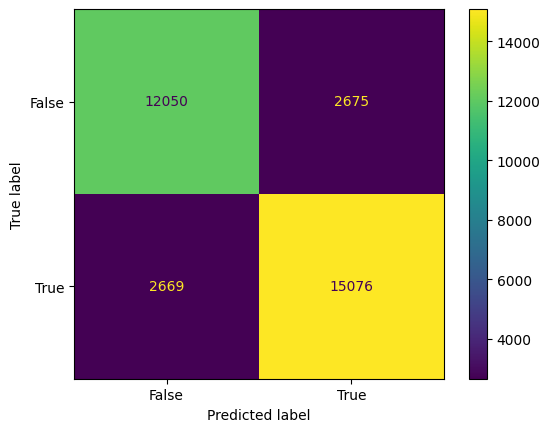

In [51]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=pipelined_model.classes_)
disp.plot()
plt.show()

In [52]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       False       0.82      0.82      0.82     14725
        True       0.85      0.85      0.85     17745

    accuracy                           0.84     32470
   macro avg       0.83      0.83      0.83     32470
weighted avg       0.84      0.84      0.84     32470



⚠️ All these metrics were computed with a probability threshold of 50%!!!

### (3.2) 🚀 Trying out all the models

In [53]:
models = [LogisticRegression(max_iter=300),
         KNeighborsClassifier(),
         SVC(kernel="rbf")]

In [54]:
%%time
list_of_accuracies = []
list_of_precisions = []
list_of_recalls = []

for model in models:
    ### MODEL NAME
    model_name_full = str(model)
    model_name = model_name_full[:model_name_full.find("(")]
    print(f"------ working with {model_name} ------")
    ### CROSS VALIDATING THE MODEL
    pipelined_model = Pipeline([
        ("preproc",preprocessor),
        (f"{model_name}",model)
        ])
    temp_cv = cross_validate(pipelined_model, X_train, y_train,
                           cv = 5,
                           scoring=["accuracy", "precision", "recall"],
                           n_jobs=-1)
    temp_accuracy = temp_cv["test_accuracy"].mean()
    temp_precision = temp_cv["test_precision"].mean()
    temp_recall = temp_cv["test_recall"].mean()
    list_of_accuracies.append(temp_accuracy)
    list_of_recalls.append(temp_recall)
    list_of_precisions.append(temp_precision)

print("✅ Done")

------ working with LogisticRegression ------
------ working with KNeighborsClassifier ------
------ working with SVC ------
✅ Done
CPU times: user 175 ms, sys: 279 ms, total: 454 ms
Wall time: 55.4 s


In [55]:
model_names = [str(model)[:str(model).find("(")] for model in models]

In [56]:
results = pd.DataFrame({
    "model":model_names,
    "accuracy":list_of_accuracies,
    "recall":list_of_recalls,
    "precision":list_of_precisions,
})

round(results.sort_values(by="accuracy", ascending = False),2)

,model,accuracy,recall,precision
2,SVC,0.93,0.94,0.93
1,KNeighborsClassifier,0.91,0.90,0.93
0,LogisticRegression,0.83,0.85,0.85


### (3.3) 🧪 Fine-tuning a model

In [57]:
svc = SVC()

In [58]:
pipelined_svc = make_pipeline(preprocessor, svc)
pipelined_svc

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scalers',
                                                                   ColumnTransformer(transformers=[('rob',
                                                                                                    RobustScaler(),
                                                                                                    ['Flight '
                                                                                                     'Distance']),
                                                                                                   ('std',
                                                                                                    StandardScaler(),
                                                                                                    ['Age']),
                                                                                                   ('mm',
                                                                                                    MinMaxScaler(),
                                                                                                    ['Seat '
                                                                                                     'comfort',
                                                                                                     'Departure/Arrival '
                                                                                                     'time '
                                                                                                     'convenient',
                                                                                                     'Food '
                                                                                                     'a...
                                                                                                                                'Eco '
                                                                                                                                'Plus',
                                                                                                                                'Business']],
                                                                                                                   dtype=<class 'numpy.int64'>,
                                                                                                                   handle_unknown='use_encoded_value',
                                                                                                                   unknown_value=-1),
                                                                                                    ['Customer '
                                                                                                     'Type',
                                                                                                     'Class']),
                                                                                                   ('one_hot',
                                                                                                    OneHotEncoder(drop='if_binary',
                                                                                                                  handle_unknown='ignore',
                                                                                                                  sparse_output=False),
                                                                                                    ['Gender',
                                            

In [59]:
pipelined_svc.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('num_pipeline',
                                    Pipeline(steps=[('imputer',
                                                     SimpleImputer(strategy='median')),
                                                    ('scalers',
                                                     ColumnTransformer(transformers=[('rob',
                                                                                      RobustScaler(),
                                                                                      ['Flight '
                                                                                       'Distance']),
                                                                                     ('std',
                                                                                      StandardScaler(),
                                                                                      ['Age'

In [60]:
param_grid = [
    # rbf kernel: C and gamma interact
    {"svc__kernel": ["rbf"],
     "svc__C"     : [0.1, 1, 10],
     "svc__gamma" : [0.01, 0.1]},

    # polynomial kernel: C, gamma and degree
    {"svc__kernel": ["poly"],
     "svc__degree": [2],
     "svc__C"     : [0.1, 1, 10]},
]

In [61]:
search = GridSearchCV(
    estimator=pipelined_svc,
    param_grid=param_grid,
    cv=5,                    # 5-fold stratified CV
    scoring=["accuracy","precision", "recall"],
    refit="accuracy",
    n_jobs=-1,               # use all CPU cores
    verbose=1
)

In [62]:
search.fit(X_train, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('num_pipeline',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scalers',
                                                                                          ColumnTransformer(transformers=[('rob',
                                                                                                                           RobustScaler(),
                                                                                                                           ['Flight '
                                                                                                                            'Distance']),
                                                                                                                          ('std',
                                                                                                                           StandardScaler(),
                                                                                                                           ['Age']),
                                                                                                                          ('mm',
                                                                                                                           MinMaxScaler(),
                                                                                                                           ['Seat '
                                                                                                                            'comfort',
                                                                                                                            'Departure/Arrival...
                                                                                                                           ['Gender',
                                                                                                                            'Type '
                                                                                                                            'of '
                                                                                                                            'Travel'])]))]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x35e424c80>)])),
                                       ('svc', SVC())]),
             n_jobs=-1,
             param_grid=[{'svc__C': [0.1, 1, 10], 'svc__gamma': [0.01, 0.1],
                          'svc__kernel': ['rbf']},
                         {'svc__C': [0.1, 1, 10], 'svc__degree': [2],
                          'svc__kernel': ['poly']}],
             refit='accuracy', scoring=['accuracy', 'precision', 'recall'],
             verbose=1)

In [63]:
search.best_score_

0.9387331896109229

In [64]:
search.best_estimator_

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scalers',
                                                                   ColumnTransformer(transformers=[('rob',
                                                                                                    RobustScaler(),
                                                                                                    ['Flight '
                                                                                                     'Distance']),
                                                                                                   ('std',
                                                                                                    StandardScaler(),
                                                                                                    ['Age']),
                                                                                                   ('mm',
                                                                                                    MinMaxScaler(),
                                                                                                    ['Seat '
                                                                                                     'comfort',
                                                                                                     'Departure/Arrival '
                                                                                                     'time '
                                                                                                     'convenient',
                                                                                                     'Food '
                                                                                                     'a...
                                                                                                                                'Business']],
                                                                                                                   dtype=<class 'numpy.int64'>,
                                                                                                                   handle_unknown='use_encoded_value',
                                                                                                                   unknown_value=-1),
                                                                                                    ['Customer '
                                                                                                     'Type',
                                                                                                     'Class']),
                                                                                                   ('one_hot',
                                                                                                    OneHotEncoder(drop='if_binary',
                                                                                                                  handle_unknown='ignore',
                                                                                                                  sparse_output=False),
                                                                                                    ['Gender',
                                                                                                     'Type '
                                                                                                     'of '
                                                                                                   

In [65]:
pd.DataFrame(search.cv_results_).sort_values(by="rank_test_recall").head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_svc__C,param_svc__gamma,param_svc__kernel,param_svc__degree,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,split4_test_accuracy,mean_test_accuracy,std_test_accuracy,rank_test_accuracy,split0_test_precision,split1_test_precision,split2_test_precision,split3_test_precision,split4_test_precision,mean_test_precision,std_test_precision,rank_test_precision,split0_test_recall,split1_test_recall,split2_test_recall,split3_test_recall,split4_test_recall,mean_test_recall,std_test_recall,rank_test_recall
5,92.558763,5.460514,12.098822,1.083995,10.0,0.10,rbf,NaN,"{'svc__C': 10, 'svc__gamma': 0.1, 'svc__kernel...",0.938097,0.936916,0.938302,0.941176,0.939175,0.938733,0.001418,1,0.941990,0.941369,0.944330,0.940833,0.941357,0.941976,0.001233,1,0.945168,0.943575,0.942913,0.952475,0.947975,0.946421,0.003494,1
3,64.990089,0.759946,15.689500,0.551243,1.0,0.10,rbf,NaN,"{'svc__C': 1, 'svc__gamma': 0.1, 'svc__kernel'...",0.921466,0.921620,0.923622,0.924751,0.927933,0.923878,0.002375,2,0.925188,0.926638,0.930905,0.925388,0.929844,0.927593,0.002349,2,0.931952,0.930546,0.929509,0.938226,0.939258,0.933898,0.004043,2
8,87.862393,1.468035,4.083068,0.024026,10.0,NaN,poly,2.0,"{'svc__C': 10, 'svc__degree': 2, 'svc__kernel'...",0.919618,0.919721,0.918899,0.921825,0.923981,0.920809,0.001862,3,0.924145,0.928068,0.928760,0.925547,0.928538,0.927012,0.001837,3,0.929515,0.925110,0.922666,0.932227,0.932977,0.928499,0.004012,3
7,54.380663,7.394323,6.524136,1.060970,1.0,NaN,poly,2.0,"{'svc__C': 1, 'svc__degree': 2, 'svc__kernel':...",0.914126,0.914177,0.914229,0.915050,0.918797,0.915276,0.001793,4,0.919355,0.921563,0.923947,0.918392,0.923708,0.921393,0.002239,4,0.924267,0.921736,0.919010,0.927259,0.928384,0.924131,0.003460,4
4,74.571072,4.621050,20.006402,0.790337,10.0,0.01,rbf,NaN,"{'svc__C': 10, 'svc__gamma': 0.01, 'svc__kerne...",0.903757,0.903963,0.903655,0.903603,0.909404,0.904876,0.002267,5,0.911781,0.913052,0.914084,0.909294,0.916145,0.912871,0.002289,5,0.912550,0.911426,0.909543,0.915261,0.918635,0.913483,0.003173,5


In [66]:
y_pred_search = search.best_estimator_.predict(X_test)

In [67]:
print(classification_report(y_test,y_pred_search))

              precision    recall  f1-score   support

       False       0.93      0.93      0.93     14725
        True       0.94      0.95      0.95     17745

    accuracy                           0.94     32470
   macro avg       0.94      0.94      0.94     32470
weighted avg       0.94      0.94      0.94     32470



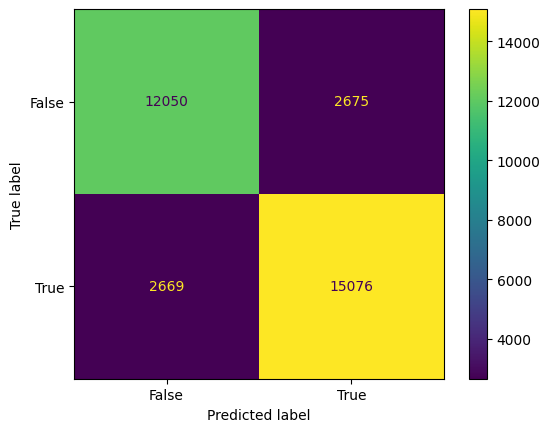

In [68]:
cm_search = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_search,
                              display_labels=search.best_estimator_.classes_)
disp.plot()
plt.show()